Part A — derivatives

Task 01

Compute derivatives by hand, verify with sympy

The bread and butter. Get fluent with the rules, then check yourself.

In [4]:
!pip install sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 39.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 25.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sympy]━━━━━ 1/2 [sympy]


In [10]:
import sympy as sp

# Symbol
x = sp.symbols('x')

# Functions
f = x**4
g = 3*x**2 + 2*x - 7
h = x**(-1)  # 1/x

# Hand Derivatives
print("Hand Derivatives : ")
print("f'(x) = 4x^3")
print("g'(x) = 6x + 2")
print("h'(x) = -x^-2 = -1/x^2")


# SymPy Derivatives
df = sp.diff(f, x)
dg = sp.diff(g, x)
dh = sp.diff(h, x)

print("\nSymPy Derivatives : ")
print("f'(x) = ", df)
print("g'(x) = ", dg)
print("h'(x) = ", dh)

# Evaluate at x = 2
x_value = 2

print("\nDerivative Values at x = 2")

# Hand Values
hand_f = 4 * (2**3)
hand_g = 6 * 2 + 2
hand_h = -(2**-2)

print("Hand : ")
print("f'(2) = ", hand_f)
print("g'(2) = ", hand_g)
print("h'(2) = ", hand_h)

# SymPy Values
print("\nSymPy : ")
print("f'(2) = ", df.subs(x, x_value))
print("g'(2) = ", dg.subs(x, x_value))
print("h'(2) = ", dh.subs(x, x_value))

# Numerical Derivative Function
def numerical_derivative(func, x, h=1e-5):
    return(func(x + h) - func(x - h) / (2 * h))

# Python Function
f_num = lambda x: x**4
g_num = lambda x: 3*x**2 + 2*x - 7
h_num = lambda x: 1/x

print("\nNumerical Derivatives at x = 2")
print("f'(2) = ", numerical_derivative(f_num, 2))
print("g'(2) = ", numerical_derivative(g_num, 2))
print("h'(2) = ", numerical_derivative(h_num, 2))

# Solve f'(x) = 0
critical_points = sp.solve(df, x)

print("\nWhere f'(x) = 0 : ")
print(critical_points)

print("\nFunction Behaviour : ")
print("For f(x) = x^4, derivative is zero at x=0.")
print("At x=0 the function reaches its minimum value and changes from decreasing to increasing.")

Hand Derivatives : 
f'(x) = 4x^3
g'(x) = 6x + 2
h'(x) = -x^-2 = -1/x^2

SymPy Derivatives : 
f'(x) =  4*x**3
g'(x) =  6*x + 2
h'(x) =  -1/x**2

Derivative Values at x = 2
Hand : 
f'(2) =  32
g'(2) =  14
h'(2) =  -0.25

SymPy : 
f'(2) =  32
g'(2) =  14
h'(2) =  -1/4

Numerical Derivatives at x = 2
f'(2) =  -799967.999799997
g'(2) =  -449983.99987499963
h'(2) =  -24999.62500312499

Where f'(x) = 0 : 
[0]

Function Behaviour : 
For f(x) = x^4, derivative is zero at x=0.
At x=0 the function reaches its minimum value and changes from decreasing to increasing.


Task 02

Plot a function against its derivative

See the relationship the notebook showed — where the derivative is zero, the function is flat.

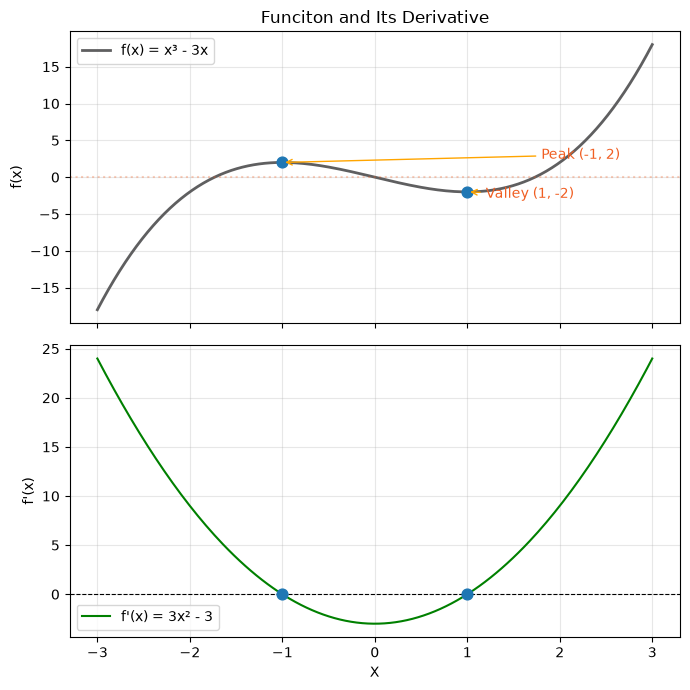

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Values
x = np.linspace(-3, 3, 200)

# Original Function
f = x**3 - 3*x

# Derivative
df = 3*x**2 - 3

# Create two panels
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

axes[0].plot(x, f, color='#5F5F60', linewidth=2, label="f(x) = x³ - 3x")
axes[0].axhline(0, color='#F05E22', linestyle=':', alpha=0.3)
axes[0].set_ylabel("f(x)")
axes[0].set_title("Funciton and Its Derivative")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Critical Points Where f'(x) = 0
critical_x = np.array([-1, 1])
critical_y = critical_x**3 - 3*critical_x

# Mark peaks and valleys
axes[0].scatter(critical_x, critical_y, s=60, zorder=3)

# Labels
axes[0].annotate("Peak (-1, 2)", (-1, 2), xytext=(1.8, 2.5),
                  arrowprops=dict(arrowstyle="->", color="orange"), color="#F05E22")

axes[0].annotate("Valley (1, -2)", (1, -2), xytext=(1.2, -2.8),
                  arrowprops=dict(arrowstyle="->", color="orange"), color="#F05E22")

# Bottom derivative
axes[1].plot(x, df, color = "green", label="f'(x) = 3x² - 3")
axes[1].axhline(0, color="black", linestyle='--', linewidth=0.8)

#Mark where derivative crosses zero
axes[1].scatter(critical_x, [0, 0], s=60, zorder=3)

axes[1].set_xlabel("X")
axes[1].set_ylabel("f'(x)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

Part B — gradients and the chain rule

TASK 03

Partial derivatives and the gradient

Move from one input to many. Build a gradient and see it point uphill.

df/dx =  2*X + Y
df/dy =  X + 4*Y
Gradient at (1, 1) = [3 5]
Gradient at (2, -1) = [ 3 -2]
Gradient at (-1, 2) = [0 7]

Point : (1, 1)
Original : 4
Uphill : 4.3474
Downhill : 3.6673999999999998
Uphill increased : True
Downhill decreased : True

Point : (2, -1)
Original : 4
Uphill : 4.131099999999999
Downhill : 3.8711
Uphill increased : True
Downhill decreased : True

Point : (-1, 2)
Original : 7
Uphill : 7.499799999999999
Downhill : 6.5198
Uphill increased : True
Downhill decreased : True


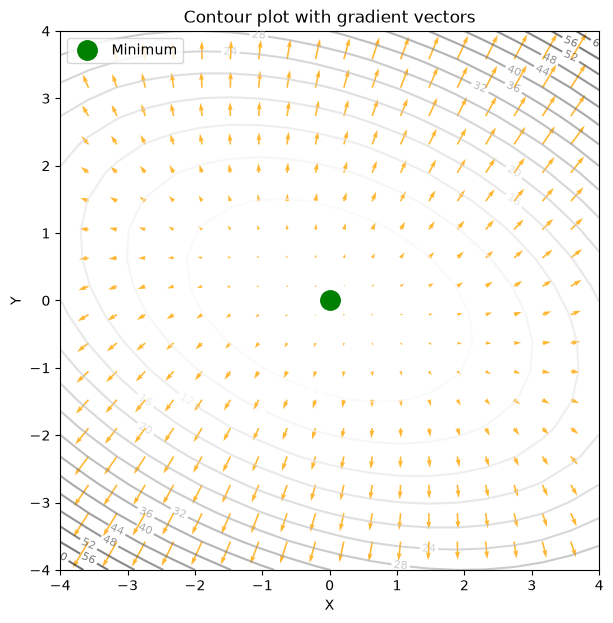

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Define Function
x, y = sp.symbols("X, Y")

f = x**2 + 2*y**2 + x*y

print("df/dx = ", sp.diff(f, x))
print("df/dy = ", sp.diff(f, y))

# Gradient Function using numpy
def gradient(px, py):
    return np.array([2*px+py, 4*py+px])

# Evaluate the gradient at three points.
points = [
    (1, 1),
    (2, -1),
    (-1, 2)
]

for px, py in points :
    print(f"Gradient at ({px}, {py}) =", gradient(px, py))

# Check uphill and downhill direction
# Convert sympy function into numerical function
f_num = sp.lambdify((x, y), f, "numpy")
step = 0.01

for px, py in points :
    g = gradient(px, py)

    original = f_num(px, py)

    uphill = f_num(px+step*g[0], py+step*g[1])

    downhill = f_num(px-step*g[0], py-step*g[1])

    print(f"\nPoint : ({px}, {py})")
    print("Original :", original)
    print("Uphill :", uphill)
    print("Downhill :", downhill)

    print("Uphill increased :", uphill > original)
    print("Downhill decreased :", downhill < original)

# Contour plot + gradient arrows
# create grid
x = np.linspace(-4, 4, 20)
y = np.linspace(-4, 4, 20)

x, y = np.meshgrid(x, y)

z = x**2 + 2*y**2 + x*y

# Gradient Components
u = 2*x+y
v = 4*y+x

fig, ax = plt.subplots(figsize=(9, 7))

contour = ax.contour(x, y, z, levels=20, cmap="Greys", alpha=0.6)
ax.clabel(contour, inline=True, fontsize=8)

# Gradient Arrows
ax.quiver(x, y, u, v, color="orange", alpha=0.8)

# Mark Minimum
ax.plot(0, 0, "o", color="green", markersize=14, label="Minimum")
ax.set_title("Contour plot with gradient vectors")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")
ax.legend()

plt.show()

TASK 04

The chain rule, by hand and in code

The most important rule for deep learning. Apply it, then verify three ways.

In [25]:
import numpy as np
import sympy as sp

# symbols
x = sp.symbols('x')

f1 = (3*x + 1)**5

print("Function 1 :")
print("f(x) :", f1)
print("SymPy Derivative :", sp.diff(f1, x))

# outer = u^4
# inner = 3x + 1

# Numerical Derivatives
def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

def func1(x):
    return (3*x + 1)**5

print("\nNumerical Verification :")

for value in [0, 1, 2] :
    exact = 15**(3*value + 1)**4
    numerical = numerical_derivative(func1, value)

    print("x =", value)
    print("Exact =", exact)
    print("Numerical =", numerical)

# f(x) = sin((2x+1)²)
f2 = sp.sin((2*x + 1)**2)

print("\n\nFunction 2 :")
print("f(x) =", f2)
print("SymPy Derivatives =", sp.diff(f2, x))

def func2(x):
    return np.sin((2*x + 1)**2)

print("\nNumerical Verification :")

for value in [0, 0.5, 1]:
    exact = 4*(2*value + 1) * np.cos((2*value + 1)**2)
    numerical = numerical_derivative(func2, value)

    print("x =", value)
    print("Exact =", exact)
    print("Numerical =", numerical)

Function 1 :
f(x) : (3*x + 1)**5
SymPy Derivative : 15*(3*x + 1)**4

Numerical Verification :
x = 0
Exact = 15
Numerical = 15.000900026995721
x = 1
Exact = 12005004253118409429987471605188977957776624287799977492662151166673905456039366611628890194329797002534475422625716662493780835906475744789275547392806271132828286402833003924382231218480102480902681818521247582530299858958345940501476654104463175029533645297476207591813590624951757490634918212890625
Numerical = 3840.0576005187754
x = 2
Exact = 6238971369835943771141009742665200857451267983249544662789149893653445825821029997509420697264970819658500891897525523084859407840188567012989510256893177886859001274669595623922132917828678925615123119895858145899171110378336583501179941341654331444269643968702455840349278895545751829871458224013391295724740665719384794544803618930499668184629736033145461605148076048138955845588464322297521221672684682892857877166537006330960599006000316934726499017794932932848788600958941069663916085244691

The chain rule multiplies derivatives because the output of one function serves as the input for another; consequently, a small change in the input affects the inner function first and then the outer function. To combine the effects of each layer, their individual rates of change must be multiplied.